In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


# Imports, config, reproducibility


In [2]:
# === CELL 1 — setup (UPDATED FIX) ===
from __future__ import annotations
import os, sys, gc, json, time, random, logging, hashlib
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd

# Bulletproof helper to find the exact folder containing the data
def get_kaggle_data_dir() -> Path:
    base_input = Path("/kaggle/input")
    if base_input.exists():
        # Search recursively for train.csv
        for file_path in base_input.rglob("train.csv"):
            return file_path.parent  # Return the exact folder containing train.csv
    return Path(".")

@dataclass(frozen=True)
class Config:
    seed: int = 42
    competition: str = "playground-series-s6e5"
    data_dir: Path = field(default_factory=get_kaggle_data_dir)
    artifacts_dir: Path = field(default_factory=lambda: Path(
        "/kaggle/working" if Path("/kaggle/working").exists() else "./artifacts"
    ))
    target: str = "PitNextLap"
    id_col: str = "id"
    # Tentative — we'll empirically validate group choice in Phase 3
    candidate_group_cols: tuple = ("Race", "Year")

CFG = Config()
CFG.artifacts_dir.mkdir(parents=True, exist_ok=True)

def set_seeds(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def get_logger(name: str = "f1") -> logging.Logger:
    lg = logging.getLogger(name)
    if lg.handlers:
        return lg
    h = logging.StreamHandler(sys.stdout)
    h.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%H:%M:%S"))
    lg.addHandler(h); lg.setLevel(logging.INFO); lg.propagate = False
    return lg

log = get_logger()
set_seeds(CFG.seed)
log.info(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")
log.info(f"Data dir: {CFG.data_dir.resolve()}")
log.info(f"Artifacts dir: {CFG.artifacts_dir.resolve()}")

09:05:27 | INFO | Python 3.12.12 | pandas 2.3.3 | numpy 2.0.2
09:05:27 | INFO | Data dir: /kaggle/input/competitions/playground-series-s6e5
09:05:27 | INFO | Artifacts dir: /kaggle/working


# Load with explicit dtypes, schema validation, and file hashes

In [3]:
# === CELL 2 — load data with schema validation ===
EXPECTED_COLS = [
    "id", "Driver", "Compound", "Race", "Year", "PitStop", "LapNumber",
    "Stint", "TyreLife", "Position", "LapTime (s)", "LapTime_Delta",
    "Cumulative_Degradation", "RaceProgress", "Position_Change", "PitNextLap",
]

DTYPES = {
    "id": "int32",
    "Driver": "category",
    "Compound": "category",
    "Race": "category",
    "Year": "int16",
    "PitStop": "int8",
    "LapNumber": "int16",
    "Stint": "int8",
    "TyreLife": "float32",
    "Position": "int8",
    "LapTime (s)": "float32",
    "LapTime_Delta": "float32",
    "Cumulative_Degradation": "float32",
    "RaceProgress": "float32",
    "Position_Change": "float32",
    "PitNextLap": "float32",
}


def _file_hash(path: Path, n_bytes: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(n_bytes), b""):
            h.update(chunk)
    return h.hexdigest()


def load_csv(path: Path, dtypes: dict) -> pd.DataFrame:
    t0 = time.time()
    df = pd.read_csv(path, dtype={k: v for k, v in dtypes.items() if k != "PitNextLap" or path.name == "train.csv"})
    log.info(f"Loaded {path.name}: shape={df.shape} | md5={_file_hash(path)[:10]} "
             f"| {time.time()-t0:.2f}s | {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    return df


def validate_schema(df: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = set(expected) - set(df.columns)
    extra = set(df.columns) - set(expected)
    if missing:
        raise ValueError(f"[{name}] missing columns: {missing}")
    if extra:
        log.warning(f"[{name}] unexpected columns: {extra}")
    log.info(f"[{name}] schema OK: {len(df.columns)} columns")


train = load_csv(CFG.data_dir / "train.csv", DTYPES)
test  = load_csv(CFG.data_dir / "test.csv",  DTYPES)
sub   = pd.read_csv(CFG.data_dir / "sample_submission.csv")

validate_schema(train, EXPECTED_COLS, "train")
validate_schema(test, [c for c in EXPECTED_COLS if c != CFG.target], "test")

# Cast target to int8 after the schema check (CSV had it as float)
train[CFG.target] = train[CFG.target].astype("int8")

print(f"\nTrain memory: {train.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Test memory:  {test.memory_usage(deep=True).sum()/1e6:.1f} MB")

09:05:28 | INFO | Loaded train.csv: shape=(439140, 16) | md5=1342f324f5 | 1.30s | 19.0 MB
09:05:29 | INFO | Loaded test.csv: shape=(188165, 15) | md5=0e20f0b82f | 0.54s | 7.4 MB
09:05:29 | INFO | [train] schema OK: 16 columns
09:05:29 | INFO | [test] schema OK: 15 columns

Train memory: 17.6 MB
Test memory:  7.4 MB


# Versioned data dictionary

In [4]:
# === CELL 3 — data dictionary ===
DATA_DICTIONARY = {
    "id": "Row identifier, unique across train+test. Not predictive.",
    "Driver": "Driver code. Mix of real F1 codes (VER, HAM, …) and synthetic IDs (D###). High cardinality (~887 in train).",
    "Compound": "Tyre compound on this lap. {HARD, MEDIUM, SOFT, INTERMEDIATE, WET}.",
    "Race": "Grand Prix name. 26 unique races.",
    "Year": "Season year, 2022–2025.",
    "PitStop": "1 if the driver pitted DURING this lap, else 0. Known at decision time — NOT a target leak.",
    "LapNumber": "Lap number in the race (1-indexed).",
    "Stint": "Stint number. Should be 1 at race start and increment after each pit. WARNING: not strictly monotonic in this synthetic dataset — see Cell 5.",
    "TyreLife": "Age of current tyre in laps. Resets to ~1 at start of each stint.",
    "Position": "Track position at end of lap (1 = leader).",
    "LapTime (s)": "Lap time in seconds.",
    "LapTime_Delta": "Pace delta vs a reference (negative = faster than reference). Engineered upstream.",
    "Cumulative_Degradation": "Engineered tyre wear metric, accumulated over stint.",
    "RaceProgress": "In [0, 1]. Encodes lap position within race; NOT a pure function of LapNumber. Carries independent info — see Cell 5.",
    "Position_Change": "Change in Position vs previous lap.",
    "PitNextLap": "TARGET. 1 if driver pits on lap (LapNumber+1), else 0.",
}

with open(CFG.artifacts_dir / "data_dictionary.json", "w") as f:
    json.dump(DATA_DICTIONARY, f, indent=2)
log.info(f"Wrote {CFG.artifacts_dir/'data_dictionary.json'}")

09:05:29 | INFO | Wrote /kaggle/working/data_dictionary.json


# Basic invariant checks (assertions)

In [5]:
# === CELL 4 — basic invariants ===
class InvariantReport(dict):
    def add(self, name, ok, detail=""):
        self[name] = {"pass": bool(ok), "detail": detail}
        marker = "✓ PASS" if ok else "✗ FAIL"
        log.info(f"  {marker}  {name}: {detail}")


report = InvariantReport()

# Nulls
report.add("train.no_nulls", train.isna().sum().sum() == 0,
           f"{int(train.isna().sum().sum())} null cells")
report.add("test.no_nulls", test.isna().sum().sum() == 0,
           f"{int(test.isna().sum().sum())} null cells")

# Global id uniqueness
all_ids = pd.concat([train["id"], test["id"]])
report.add("ids.unique_global", all_ids.is_unique,
           f"{all_ids.nunique():,} unique across train+test")

# Target binary
uniq_target = sorted(train[CFG.target].unique().tolist())
report.add("target.binary", uniq_target == [0, 1], f"values={uniq_target}")

# Test levels are subset of train (matters for encoding strategy)
for col in ["Driver", "Race", "Year", "Compound"]:
    unseen = set(test[col].unique()) - set(train[col].unique())
    report.add(f"test.{col}.subset_of_train", len(unseen) == 0,
               f"{len(unseen)} unseen levels")

# Train/test laps disjoint within each (Driver, Race, Year)
tr_keys = set(zip(train["Driver"], train["Race"], train["Year"], train["LapNumber"]))
te_keys = set(zip(test["Driver"], test["Race"], test["Year"], test["LapNumber"]))
report.add("train.test.lap_disjoint", len(tr_keys & te_keys) == 0,
           f"{len(tr_keys & te_keys)} overlapping rows")

09:05:29 | INFO |   ✓ PASS  train.no_nulls: 0 null cells
09:05:29 | INFO |   ✓ PASS  test.no_nulls: 0 null cells
09:05:29 | INFO |   ✓ PASS  ids.unique_global: 627,305 unique across train+test
09:05:29 | INFO |   ✓ PASS  target.binary: values=[0, 1]
09:05:29 | INFO |   ✓ PASS  test.Driver.subset_of_train: 0 unseen levels
09:05:29 | INFO |   ✓ PASS  test.Race.subset_of_train: 0 unseen levels
09:05:29 | INFO |   ✓ PASS  test.Year.subset_of_train: 0 unseen levels
09:05:29 | INFO |   ✓ PASS  test.Compound.subset_of_train: 0 unseen levels
09:05:30 | INFO |   ✓ PASS  train.test.lap_disjoint: 0 overlapping rows


# Anomaly investigation

In [6]:
# === CELL 5 — anomalies that reshape strategy ===
print("="*72)
print("ANOMALY 1: Stint is NOT monotonic within (Driver, Race, Year)")
print("="*72)
full = pd.concat([
    train[["Driver","Race","Year","LapNumber","Stint","PitStop"]].assign(src="train"),
    test[["Driver","Race","Year","LapNumber","Stint","PitStop"]].assign(src="test"),
], ignore_index=True).sort_values(["Driver","Race","Year","LapNumber"])
full["stint_diff"] = full.groupby(["Driver","Race","Year"])["Stint"].diff()
n_dec = int((full["stint_diff"] < 0).sum())
print(f"Stint decreases observed within (Driver, Race, Year): {n_dec:,}")

# Show a concrete example so it's tangible
bad = full[full["stint_diff"] < 0].iloc[0]
d, r, y = bad["Driver"], bad["Race"], bad["Year"]
print(f"\nExample group — {d} | {r} | {y}:")
print(full[(full["Driver"]==d)&(full["Race"]==r)&(full["Year"]==y)]
      [["LapNumber","Stint","PitStop","src"]].to_string(index=False))
print("""
INTERPRETATION:
  Within a (Driver, Race, Year) group, Stint should only increase. It doesn't.
  The cleanest explanation is that the synthetic generator sampled each row
  independently from a conditional distribution, NOT as a coherent race
  simulation. Different rows of the same nominal group are samples from
  different latent race instances.

IMPLICATION FOR PHASE 4:
  - DO NOT build lag/lead features within (Driver, Race, Year) — they would
    mix samples from different latent instances.
  - Within-row features (TyreLife, Compound, Stint, LapTime_Delta, etc.) are
    valid and carry all the signal we need.
  - Treat rows as effectively i.i.d. for modeling.
""")

print("="*72)
print("ANOMALY 2: 2023 is a regime shift")
print("="*72)
yr = train.groupby("Year")[CFG.target].agg(["mean","sum","count"])
yr.columns = ["pos_rate", "n_positives", "n_rows"]
print(yr)
print("""
INTERPRETATION:
  2023 has positive rate of ~1% vs ~27% for other years. The synthetic
  generator clearly used different parameters for 2023.

IMPLICATION:
  - Year is a top-tier feature. Tree models will discover this naturally.
  - For linear models, one-hot Year or use it in interactions with Compound.
  - Be careful with stratified CV: stratify on Year as well as target.
""")

print("="*72)
print("ANOMALY 3: RaceProgress is independent of LapNumber/MaxLap")
print("="*72)
full_lap = pd.concat([train[["Race","Year","LapNumber"]],
                      test[["Race","Year","LapNumber"]]], ignore_index=True)
max_lap = full_lap.groupby(["Race","Year"])["LapNumber"].transform("max")
implied = pd.concat([train["LapNumber"], test["LapNumber"]]).values / max_lap.values
actual  = pd.concat([train["RaceProgress"], test["RaceProgress"]]).values
err = np.abs(actual - implied)
print(f"Max abs error |RaceProgress - LapNumber/MaxLap| = {err.max():.4f}")
print(f"Mean abs error                                  = {err.mean():.4f}")
print("""
INTERPRETATION:
  Different rows of the same (Race, Year) imply different race lengths.
  RaceProgress is row-specific, not (Race, Year)-specific — so the same
  nominal race has multiple latent instances with different lap counts.

IMPLICATION:
  - Keep both LapNumber AND RaceProgress as features.
  - RaceProgress encodes "how far into THIS particular race instance" — a
    more semantically meaningful 'time' feature than raw LapNumber.
""")

print("="*72)
print("ANOMALY 4: Final-lap PitNextLap is NOT zero")
print("="*72)
true_max = full_lap.groupby(["Race","Year"])["LapNumber"].max().rename("true_max")
tr2 = train.merge(true_max, on=["Race","Year"])
last_mask = tr2["LapNumber"] == tr2["true_max"]
print(f"Train rows on race-max lap: {last_mask.sum()}")
print(f"  P(PitNextLap=1 | race-max lap, all years): {tr2.loc[last_mask, CFG.target].mean():.4f}")
print(f"  P(PitNextLap=1 | race-max lap, 2022):     {tr2.loc[last_mask&(tr2['Year']==2022), CFG.target].mean():.4f}")
print(f"  P(PitNextLap=1 | race-max lap, 2023):     {tr2.loc[last_mask&(tr2['Year']==2023), CFG.target].mean():.4f}")
print("""
INTERPRETATION:
  "Final lap" by max-lap definition still has ~30% positive rate. This is
  consistent with Anomaly 3 — the row's actual race instance may end LATER
  than max_lap in (Race, Year). So we don't know which rows are truly final.

IMPLICATION:
  - Do NOT hard-code 0 for high-LapNumber rows.
  - Let the model learn this from RaceProgress.
""")

ANOMALY 1: Stint is NOT monotonic within (Driver, Race, Year)


/tmp/ipykernel_16/3082693763.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full["stint_diff"] = full.groupby(["Driver","Race","Year"])["Stint"].diff()
/tmp/ipykernel_16/3082693763.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_lap = full_lap.groupby(["Race","Year"])["LapNumber"].transform("max")


Stint decreases observed within (Driver, Race, Year): 79,081

Example group — ALB | Abu Dhabi Grand Prix | 2023:
 LapNumber  Stint  PitStop   src
         1      1        0 train
         5      1        0 train
         7      1        0 train
         9      1        0 train
        16      1        0 train
        17      3        0  test
        18      1        0 train
        19      1        0 train
        20      1        0  test
        21      1        0 train
        23      1        0  test
        25      2        0  test
        26      2        0  test
        27      2        0  test
        29      1        0 train
        32      2        0 train
        37      2        0 train
        43      3        0 train
        49      3        0 train
        56      2        0 train
        57      2        0 train
        58      3        0 train

INTERPRETATION:
  Within a (Driver, Race, Year) group, Stint should only increase. It doesn't.
  The cleanest explanation is th

/tmp/ipykernel_16/3082693763.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  true_max = full_lap.groupby(["Race","Year"])["LapNumber"].max().rename("true_max")


# Train/Test topology

In [7]:
# === CELL 6 — train/test split topology ===
tr_groups = set(zip(train["Driver"], train["Race"], train["Year"]))
te_groups = set(zip(test["Driver"], test["Race"], test["Year"]))

print("=== (Driver, Race, Year) group topology ===")
print(f"  Train groups:       {len(tr_groups):>7,}")
print(f"  Test groups:        {len(te_groups):>7,}")
print(f"  Shared groups:      {len(tr_groups & te_groups):>7,}")
print(f"  Test-only groups:   {len(te_groups - tr_groups):>7,}")
print(f"  Train-only groups:  {len(tr_groups - te_groups):>7,}")

# Train fraction per shared group
g_tr = train.groupby(["Driver","Race","Year"]).size().rename("n_train")
g_te = test.groupby(["Driver","Race","Year"]).size().rename("n_test")
counts = pd.concat([g_tr, g_te], axis=1).fillna(0).astype(int)
counts["total"] = counts.sum(axis=1)
counts["train_frac"] = counts["n_train"] / counts["total"]
print("\nLaps per group — train-fraction distribution:")
print(counts["train_frac"].describe().to_string())

print("""
KEY TAKEAWAY FOR PHASE 3:
  The test set is NOT a held-out set of unseen races. It's a random row-level
  hold-out from the same races. This means:
   - Random KFold on rows mirrors the actual public/private split mechanism.
   - GroupKFold on (Race, Year) would be PESSIMISTIC (model never sees those
     races during CV training, but at submission time it does).
   - Target encoding leakage is the real risk — handle with out-of-fold
     target encoding INSIDE each fold's training, not group-level CV.
  We will validate these claims empirically with both CV schemes in Phase 3.
""")

=== (Driver, Race, Year) group topology ===
  Train groups:        40,869
  Test groups:         37,038
  Shared groups:       35,674
  Test-only groups:     1,364
  Train-only groups:    5,195

Laps per group — train-fraction distribution:
count    42233.000000
mean         0.700627
std          0.199137
min          0.000000
25%          0.615385
50%          0.714286
75%          0.800000
max          1.000000

KEY TAKEAWAY FOR PHASE 3:
  The test set is NOT a held-out set of unseen races. It's a random row-level
  hold-out from the same races. This means:
   - Random KFold on rows mirrors the actual public/private split mechanism.
   - GroupKFold on (Race, Year) would be PESSIMISTIC (model never sees those
     races during CV training, but at submission time it does).
   - Target encoding leakage is the real risk — handle with out-of-fold
     target encoding INSIDE each fold's training, not group-level CV.
  We will validate these claims empirically with both CV schemes in Phase 

/tmp/ipykernel_16/1280441799.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_tr = train.groupby(["Driver","Race","Year"]).size().rename("n_train")
/tmp/ipykernel_16/1280441799.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_te = test.groupby(["Driver","Race","Year"]).size().rename("n_test")


# Univariate signal sanity

In [8]:
# === CELL 7 — feature-target relationships ===
print("=== Positive rate by Compound ===")
print(train.groupby("Compound", observed=True)[CFG.target]
        .agg(["mean", "count"]).sort_values("mean", ascending=False))

print("\n=== Positive rate by TyreLife bucket ===")
tl_b = pd.cut(train["TyreLife"], [0,5,10,15,20,30,50,100], right=False)
print(train.groupby(tl_b, observed=True)[CFG.target].agg(["mean","count"]))

print("\n=== Positive rate by Stint ===")
print(train.groupby("Stint")[CFG.target].agg(["mean","count"]))

print("\n=== Positive rate by RaceProgress decile ===")
rp = pd.qcut(train["RaceProgress"], 10, duplicates="drop")
print(train.groupby(rp, observed=True)[CFG.target].agg(["mean","count"]))

print("\n=== PitStop (current lap) vs PitNextLap ===")
print(pd.crosstab(train["PitStop"], train[CFG.target], normalize="index"))

print("""
SIGNAL EXPECTATIONS:
  - TyreLife should monotonically increase pit prob — confirms the obvious prior.
  - Compound: HARD pits most often (long stints), WET barely at all.
  - Stint=1 has very different prior than Stint=2 (people don't pit immediately).
  - RaceProgress: pit rate likely peaks in mid-race (strategic windows).
  - PitStop=1 currently → much lower P(PitNextLap=1) (just changed tyres).
  These will be the dominant features for any baseline model.
""")

=== Positive rate by Compound ===
                  mean   count
Compound                      
HARD          0.327537  170518
SOFT          0.193475   38744
INTERMEDIATE  0.152284   17382
MEDIUM        0.101131  211141
WET           0.025092    1355

=== Positive rate by TyreLife bucket ===
               mean  count
TyreLife                  
[0, 5)     0.041802  72341
[5, 10)    0.119404  92660
[10, 15)   0.183493  90652
[15, 20)   0.251436  68932
[20, 30)   0.318365  81196
[30, 50)   0.390368  31747
[50, 100)  0.672457   1612

=== Positive rate by Stint ===
           mean   count
Stint                  
1      0.059818  216288
2      0.391104  129536
3      0.293105   69238
4      0.171666   18903
5      0.053025    4281
6      0.019231     728
7      0.000000     116
8      0.020000      50

=== Positive rate by RaceProgress decile ===
                                    mean  count
RaceProgress                                   
(0.011800000000000001, 0.0526]  0.055418  44715
(0

# Persist artifacts for downstream phases

In [9]:
# === CELL 8 — save artifacts ===
# Try parquet (faster, ~5x smaller); fall back to feather; fall back to pickle.
def smart_save(df: pd.DataFrame, stem: str) -> Path:
    for ext, writer in [
        (".parquet", lambda p: df.to_parquet(p, index=False)),
        (".feather", lambda p: df.reset_index(drop=True).to_feather(p)),
        (".pkl",     lambda p: df.to_pickle(p)),
    ]:
        p = CFG.artifacts_dir / f"{stem}{ext}"
        try:
            writer(p); log.info(f"Saved {p.name} ({p.stat().st_size/1e6:.1f} MB)")
            return p
        except Exception as e:
            log.warning(f"  {ext} write failed: {e}")
    raise RuntimeError("No serializer worked")


smart_save(train, "train")
smart_save(test, "test")

with open(CFG.artifacts_dir / "invariants.json", "w") as f:
    json.dump(dict(report), f, indent=2)
log.info(f"Wrote {CFG.artifacts_dir/'invariants.json'}")

09:05:31 | INFO | Saved train.parquet (9.0 MB)
09:05:31 | INFO | Saved test.parquet (4.2 MB)
09:05:31 | INFO | Wrote /kaggle/working/invariants.json


# Phase 1 knowledge checklist

In [10]:
# === CELL 9 — wrap-up ===
print("""
============================================================================
                    PHASE 1 KNOWLEDGE CHECKLIST
============================================================================

DATA SHAPE
  • Train 439,140 rows × 16 cols, Test 188,165 rows × 15 cols
  • No nulls, all dtypes pinned, ~18 MB train in memory
  • Target prevalence: 19.9% positive (moderate imbalance — no resampling)

CATEGORICAL CARDINALITY
  • Driver: ~887 levels (high cardinality, mix of real codes + synthetic D###)
  • Race: 26, Compound: 5, Year: 4
  • All test levels are seen in train → safe for OHE OR target encoding

CRITICAL FINDING #1 — synthetic data is row-i.i.d. not sequence-coherent
  • Stint goes BACKWARDS within (Driver, Race, Year) groups (79k cases)
  • RaceProgress is row-specific, not (Race,Year)-deterministic
  • Implication: NO within-group lag features in Phase 4
  • Implication: each row is effectively independent — model as flat tabular

CRITICAL FINDING #2 — 2023 is a regime shift
  • 2023 positive rate ~1% vs ~27% in other years
  • Year is a top-3 feature; stratify CV on (target × Year)

CRITICAL FINDING #3 — train/test are row-level random splits of same races
  • 35,674 of 37,038 test groups also appear in train
  • CV strategy implication: row-level KFold mirrors actual test split
  • Target-encoding leakage is the actual risk — handle with OOF encoding

STRONG SIGNALS CONFIRMED
  • TyreLife (mean 19.5 when pitting vs 12.8 when not)
  • Compound × TyreLife interaction
  • Stint number, RaceProgress, current-lap PitStop status

ENGINEERED COLUMNS PRESENT — audit in Phase 2 for redundancy / quality
  • LapTime_Delta, Cumulative_Degradation, RaceProgress, Position_Change

ARTIFACTS WRITTEN
  • data_dictionary.json — column semantics
  • invariants.json      — automated check results
  • train.{parquet|feather|pkl}, test.{...} — fast reload for later phases


""")


                    PHASE 1 KNOWLEDGE CHECKLIST

DATA SHAPE
  • Train 439,140 rows × 16 cols, Test 188,165 rows × 15 cols
  • No nulls, all dtypes pinned, ~18 MB train in memory
  • Target prevalence: 19.9% positive (moderate imbalance — no resampling)

CATEGORICAL CARDINALITY
  • Driver: ~887 levels (high cardinality, mix of real codes + synthetic D###)
  • Race: 26, Compound: 5, Year: 4
  • All test levels are seen in train → safe for OHE OR target encoding

CRITICAL FINDING #1 — synthetic data is row-i.i.d. not sequence-coherent
  • Stint goes BACKWARDS within (Driver, Race, Year) groups (79k cases)
  • RaceProgress is row-specific, not (Race,Year)-deterministic
  • Implication: NO within-group lag features in Phase 4
  • Implication: each row is effectively independent — model as flat tabular

CRITICAL FINDING #2 — 2023 is a regime shift
  • 2023 positive rate ~1% vs ~27% in other years
  • Year is a top-3 feature; stratify CV on (target × Year)

CRITICAL FINDING #3 — train/test a

# PHASE 02, 

## Setup & Load Phase 1 Artifacts

In [11]:
# === CELL 10 — Setup & Load ===
import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif, f_classif

# Mute harmless seaborn warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Styling for dark-themed Kaggle / clean visuals
plt.style.use('dark_background')
sns.set_palette("viridis")

artifacts_dir = Path("/kaggle/working" if Path("/kaggle/working").exists() else "./artifacts")

# Load the lightweight parquet from Phase 1
train = pd.read_parquet(artifacts_dir / "train.parquet")
target = "PitNextLap"

print(f"Loaded train from parquet: {train.shape}")
print(f"Memory: {train.memory_usage(deep=True).sum()/1e6:.1f} MB")

Loaded train from parquet: (439140, 16)
Memory: 17.6 MB


# EDA setup

In [12]:
# === CELL 10 — EDA setup ===
import numpy as np, pandas as pd, json, gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
sns.set_palette("deep")

# If train/test are still in memory from Phase 1, skip this. Otherwise reload.
try:
    train  # noqa
except NameError:
    try:
        train = pd.read_parquet("/kaggle/working/train.parquet")
        test  = pd.read_parquet("/kaggle/working/test.parquet")
    except Exception:
        train = pd.read_csv("/kaggle/input/playground-series-s6e5/train.csv")
        test  = pd.read_csv("/kaggle/input/playground-series-s6e5/test.csv")
        for c in ["Driver","Compound","Race"]:
            train[c] = train[c].astype("category")
            test[c]  = test[c].astype("category")
        train["PitNextLap"] = train["PitNextLap"].astype("int8")

TARGET = "PitNextLap"
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Target prevalence: {train[TARGET].mean():.4f}")

Train: (439140, 16), Test: (188165, 15)
Target prevalence: 0.1990


# Univariate distributions of numeric features

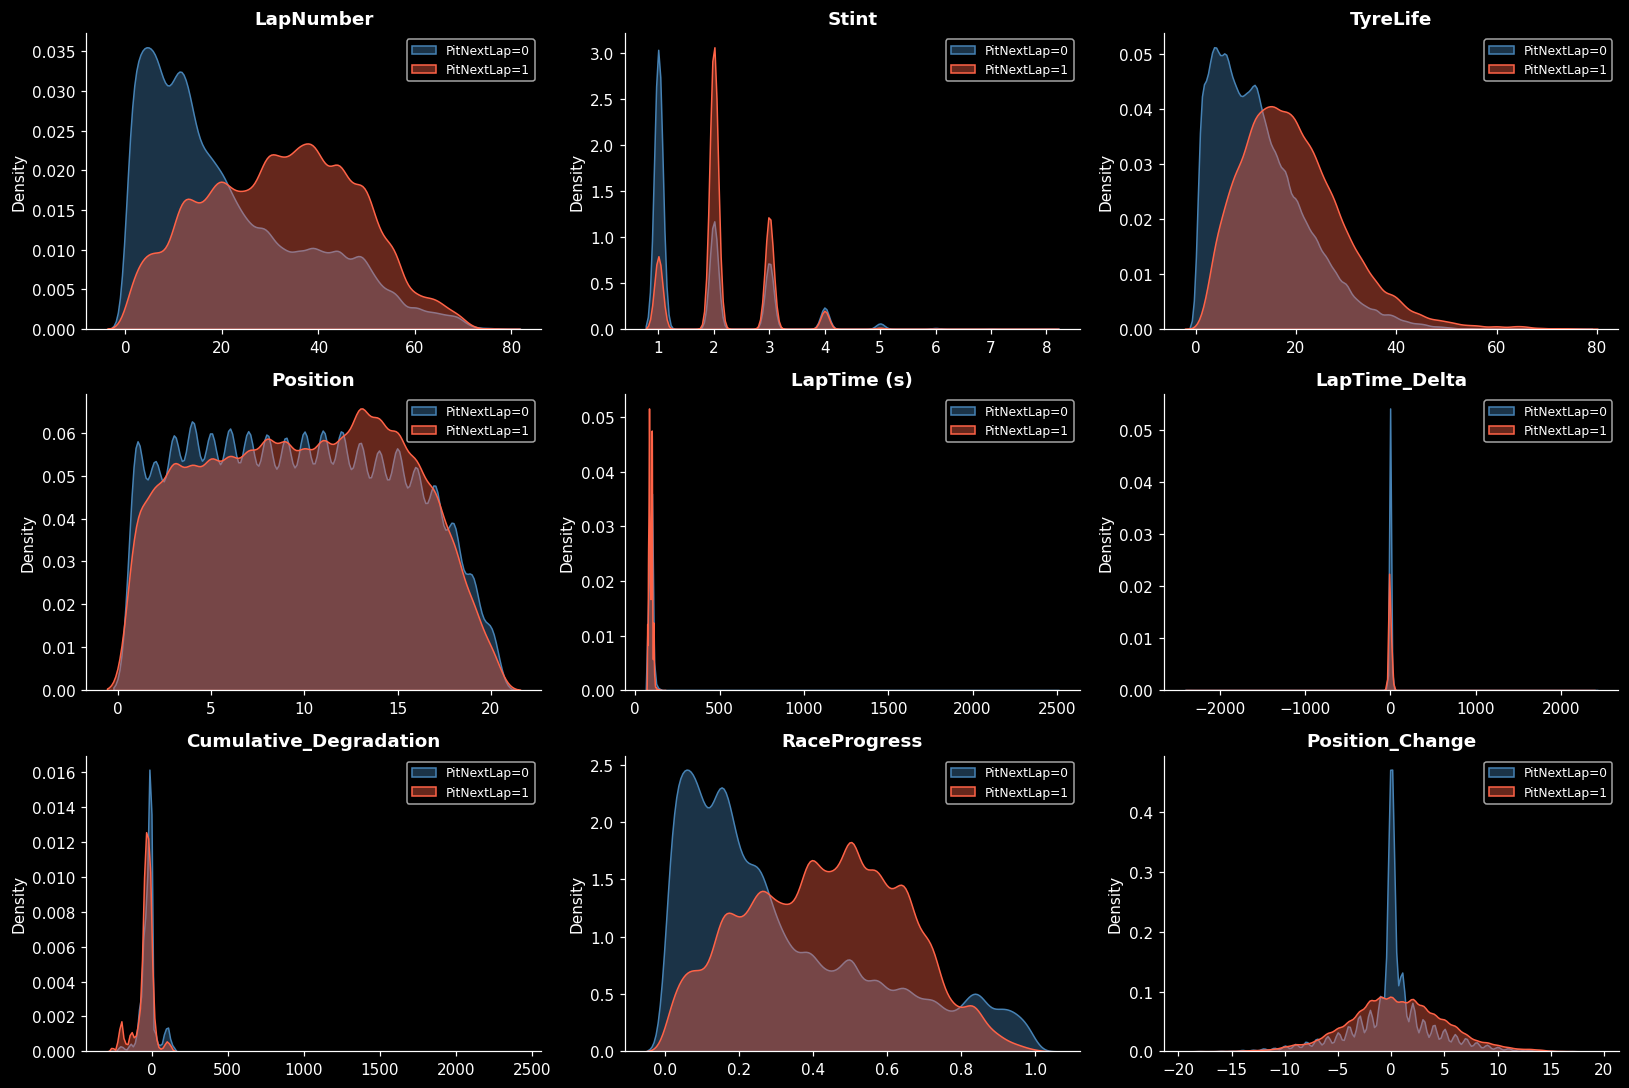

In [13]:
# === CELL 11 — numeric distributions, split by target ===
num_cols = ["LapNumber","Stint","TyreLife","Position","LapTime (s)",
            "LapTime_Delta","Cumulative_Degradation","RaceProgress","Position_Change"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        sns.kdeplot(train.loc[train[TARGET]==label, col],
                    ax=ax, label=f"PitNextLap={label}",
                    fill=True, alpha=0.4, color=color, common_norm=False)
    ax.set_title(col); ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Mutual information ranking

               feature       mi
          RaceProgress 0.090774
                 Stint 0.076236
                  Year 0.069725
         LapTime_Delta 0.057902
Cumulative_Degradation 0.049614
              TyreLife 0.042573
             LapNumber 0.041395
       Position_Change 0.037861
              Compound 0.034503
           LapTime (s) 0.023735
                  Race 0.017974
                Driver 0.015409
              Position 0.001379
               PitStop 0.000863


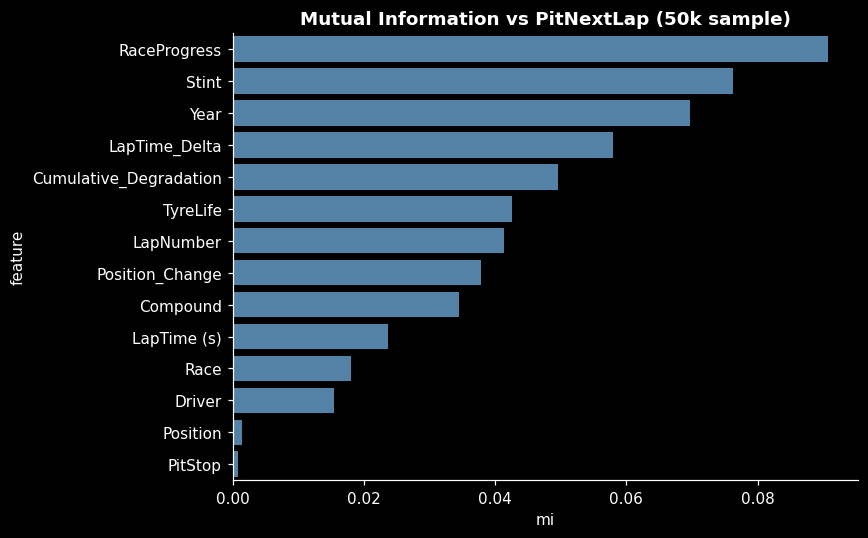

In [14]:
# === CELL 12 — feature ranking by MI ===
from sklearn.preprocessing import OrdinalEncoder

# MI works on dense numeric arrays; encode cats as ordinals
mi_features = num_cols + ["Compound", "Year", "Driver", "Race", "PitStop"]
X_mi = train[mi_features].copy()
for c in ["Compound","Year","Driver","Race","PitStop"]:
    X_mi[c] = OrdinalEncoder().fit_transform(X_mi[[c]].astype(str))

# Use a sample for speed (MI is O(n log n))
sample_idx = np.random.RandomState(42).choice(len(X_mi), 50_000, replace=False)
mi = mutual_info_classif(X_mi.iloc[sample_idx].values,
                         train[TARGET].iloc[sample_idx].values,
                         discrete_features=[X_mi.columns.get_loc(c) for c in
                                            ["Compound","Year","Driver","Race","PitStop"]],
                         random_state=42)
mi_df = pd.DataFrame({"feature": mi_features, "mi": mi}).sort_values("mi", ascending=False)
print(mi_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=mi_df, y="feature", x="mi", color="steelblue")
plt.title("Mutual Information vs PitNextLap (50k sample)")
plt.tight_layout(); plt.show()

# The Compound × TyreLife interaction (the dominant signal)

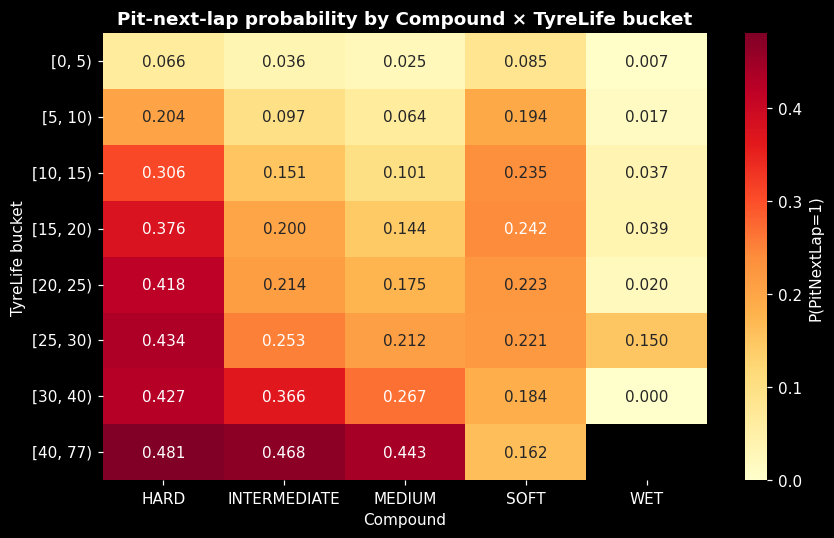


P(pit_next | compound, tyre_life_bucket):
Compound   HARD  INTERMEDIATE  MEDIUM   SOFT    WET
TyreLife                                           
[0, 5)    0.066         0.036   0.025  0.085  0.007
[5, 10)   0.204         0.097   0.064  0.194  0.017
[10, 15)  0.306         0.151   0.101  0.235  0.037
[15, 20)  0.376         0.200   0.144  0.242  0.039
[20, 25)  0.418         0.214   0.175  0.223  0.020
[25, 30)  0.434         0.253   0.212  0.221  0.150
[30, 40)  0.427         0.366   0.267  0.184  0.000
[40, 77)  0.481         0.468   0.443  0.162    NaN


In [15]:
# === CELL 13 — Compound x TyreLife pit rate heatmap ===
tl_bin = pd.cut(train["TyreLife"], bins=[0,5,10,15,20,25,30,40,77], right=False)
pivot = (train.groupby(["Compound", tl_bin], observed=True)[TARGET]
              .mean().unstack("Compound"))

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
            cbar_kws={"label": "P(PitNextLap=1)"})
plt.title("Pit-next-lap probability by Compound × TyreLife bucket")
plt.ylabel("TyreLife bucket"); plt.xlabel("Compound")
plt.tight_layout(); plt.show()

# Same table, raw numbers, in console
print("\nP(pit_next | compound, tyre_life_bucket):")
print(pivot.round(3).to_string())

# Year × Compound (regime shift visualization)

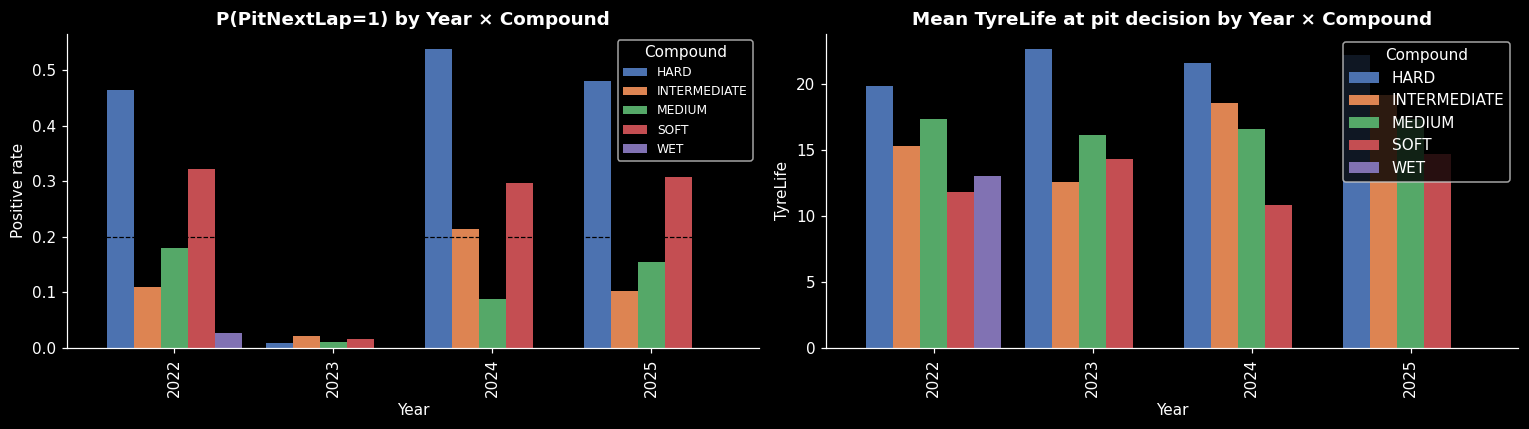

In [16]:
# === CELL 14 — 2023 regime shift visualization ===
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

yc = (train.groupby(["Year","Compound"], observed=True)[TARGET]
            .mean().unstack("Compound"))
yc.plot(kind="bar", ax=ax[0], width=0.85)
ax[0].set_title("P(PitNextLap=1) by Year × Compound")
ax[0].set_ylabel("Positive rate"); ax[0].legend(title="Compound", fontsize=8)
ax[0].axhline(train[TARGET].mean(), ls="--", c="k", lw=0.8, label="overall")

# Mean TyreLife at pit decision (proxy for stint length)
pit_rows = train[train[TARGET]==1]
yl = pit_rows.groupby(["Year","Compound"], observed=True)["TyreLife"].mean().unstack("Compound")
yl.plot(kind="bar", ax=ax[1], width=0.85)
ax[1].set_title("Mean TyreLife at pit decision by Year × Compound")
ax[1].set_ylabel("TyreLife")
plt.tight_layout(); plt.show()

# RaceProgress: the strategic-window hypothesis

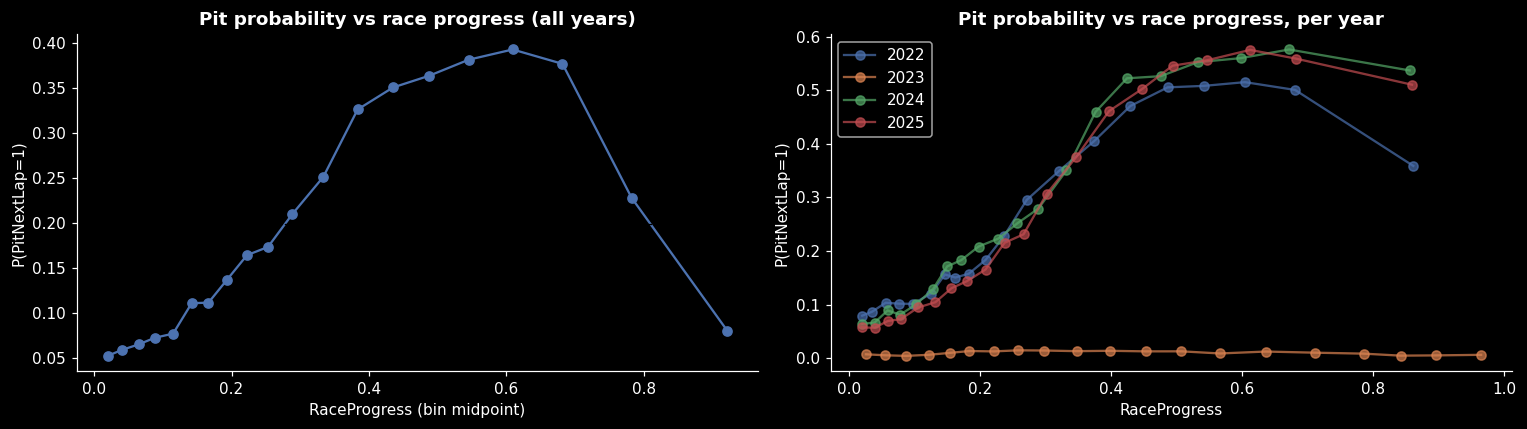

In [17]:
# === CELL 15 — pit probability across race progress ===
rp_bin = pd.qcut(train["RaceProgress"], 20, duplicates="drop")
rate = train.groupby(rp_bin, observed=True)[TARGET].agg(["mean","count"])
rate["bin_mid"] = [iv.mid for iv in rate.index]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(rate["bin_mid"], rate["mean"], "o-")
ax[0].set_xlabel("RaceProgress (bin midpoint)")
ax[0].set_ylabel("P(PitNextLap=1)")
ax[0].set_title("Pit probability vs race progress (all years)")
ax[0].axhline(train[TARGET].mean(), ls="--", c="k", lw=0.8)

# Per-year overlay
for yr in sorted(train["Year"].unique()):
    sub = train[train["Year"]==yr]
    if len(sub) < 1000: continue
    rb = pd.qcut(sub["RaceProgress"], 20, duplicates="drop")
    r = sub.groupby(rb, observed=True)[TARGET].mean()
    ax[1].plot([iv.mid for iv in r.index], r.values, "o-", label=str(yr), alpha=0.7)
ax[1].set_xlabel("RaceProgress"); ax[1].set_ylabel("P(PitNextLap=1)")
ax[1].set_title("Pit probability vs race progress, per year")
ax[1].legend()
plt.tight_layout(); plt.show()

# Driver-level signal: should we trust per-driver patterns?

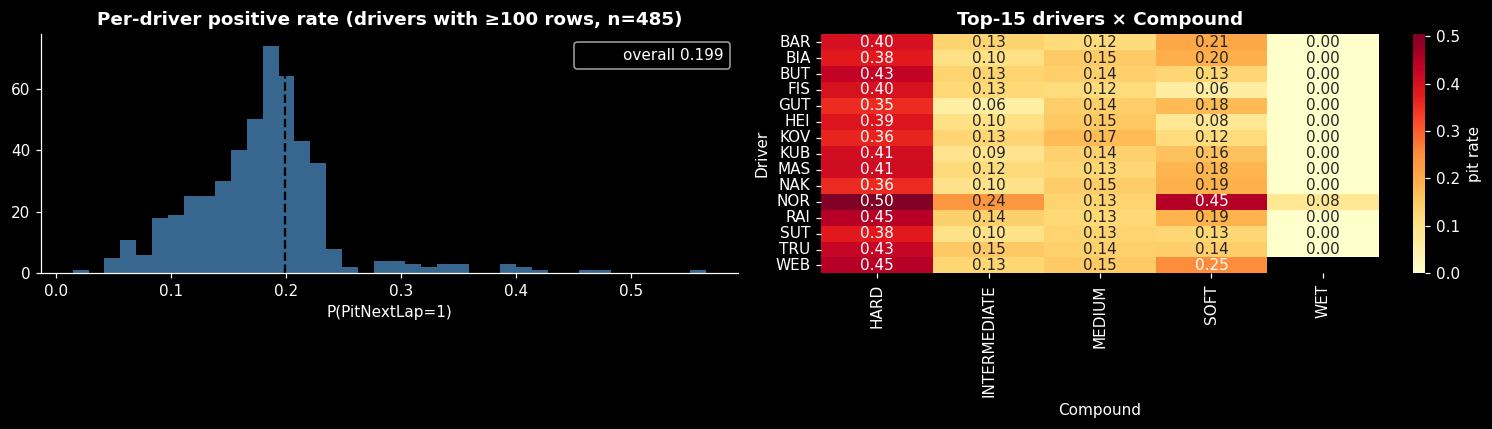


Driver pos-rate std: 0.0639
Driver pos-rate range: [0.014, 0.565]


In [18]:
# === CELL 16 — driver-level signal ===
# Per-driver positive rate distribution
driver_stats = train.groupby("Driver", observed=True).agg(
    n=(TARGET, "size"),
    pos_rate=(TARGET, "mean")
).query("n >= 100")  # filter for stable estimates

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(driver_stats["pos_rate"], bins=40, color="steelblue", alpha=0.8)
ax[0].axvline(train[TARGET].mean(), ls="--", c="k", label=f"overall {train[TARGET].mean():.3f}")
ax[0].set_title(f"Per-driver positive rate (drivers with ≥100 rows, n={len(driver_stats)})")
ax[0].set_xlabel("P(PitNextLap=1)"); ax[0].legend()

# Driver × Compound interaction sample
top_drivers = driver_stats.nlargest(15, "n").index
dc = (train[train["Driver"].isin(top_drivers)]
        .groupby(["Driver","Compound"], observed=True)[TARGET]
        .mean().unstack("Compound"))
sns.heatmap(dc, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax[1],
            cbar_kws={"label":"pit rate"})
ax[1].set_title("Top-15 drivers × Compound")
plt.tight_layout(); plt.show()

print(f"\nDriver pos-rate std: {driver_stats['pos_rate'].std():.4f}")
print(f"Driver pos-rate range: [{driver_stats['pos_rate'].min():.3f}, "
      f"{driver_stats['pos_rate'].max():.3f}]")

# Conditional dependencies: PitStop (current) → PitNextLap

In [19]:
# === CELL 17 — conditional structure of the immediate-pit transition ===
ct = pd.crosstab(train["PitStop"], train[TARGET], normalize="index")
ct.columns = ["P(PitNextLap=0)", "P(PitNextLap=1)"]
print("=== Conditional given current-lap PitStop ===")
print(ct)

# When PitStop=1 (just pitted), the next-lap pit rate should be near 0
# (drivers don't pit two consecutive laps). Verify.
recent_pit = train[train["PitStop"]==1]
print(f"\nRows where PitStop=1: {len(recent_pit):,}")
print(f"P(PitNextLap=1 | PitStop=1): {recent_pit[TARGET].mean():.4f}")

# Position changes vs pit decision
pc_bin = pd.cut(train["Position_Change"], [-10,-3,-1,0,1,3,10])
print("\n=== P(PitNextLap=1 | Position_Change bucket) ===")
print(train.groupby(pc_bin, observed=True)[TARGET].agg(["mean","count"]))

=== Conditional given current-lap PitStop ===
         P(PitNextLap=0)  P(PitNextLap=1)
PitStop                                  
0               0.808715         0.191285
1               0.752171         0.247829

Rows where PitStop=1: 59,775
P(PitNextLap=1 | PitStop=1): 0.2478

=== P(PitNextLap=1 | Position_Change bucket) ===
                     mean   count
Position_Change                  
(-10, -3]        0.263631   74938
(-3, -1]         0.265560   57550
(-1, 0]          0.057486  137668
(0, 1]           0.168930   41603
(1, 3]           0.287002   49484
(3, 10]          0.310623   63759


# Correlation matrix among numeric features

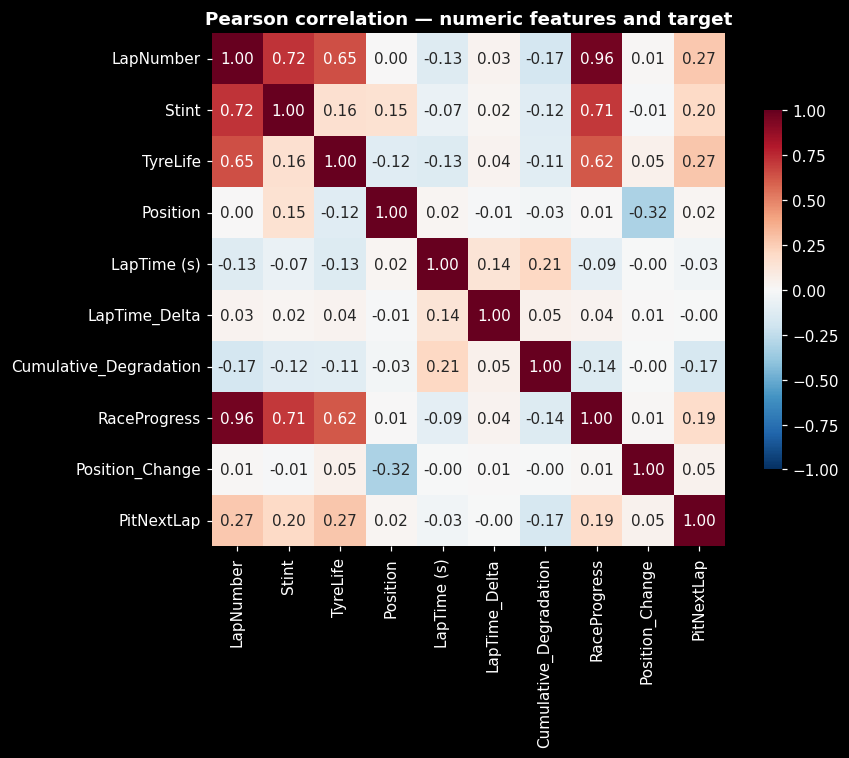

Feature pairs with |corr| > 0.5:
RaceProgress  LapNumber       0.964539
LapNumber     RaceProgress    0.964539
Stint         LapNumber       0.724390
LapNumber     Stint           0.724390
RaceProgress  Stint           0.710020
Stint         RaceProgress    0.710020
LapNumber     TyreLife        0.648408
TyreLife      LapNumber       0.648408
              RaceProgress    0.622660
RaceProgress  TyreLife        0.622660
dtype: float64


In [20]:
# === CELL 18 — correlation matrix ===
corr = train[num_cols + [TARGET]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7})
plt.title("Pearson correlation — numeric features and target")
plt.tight_layout(); plt.show()

# Highly correlated feature pairs (>|0.5|, excluding self)
high_corr = corr.where(np.abs(corr) > 0.5)
high_corr = high_corr.unstack().dropna()
high_corr = high_corr[high_corr.index.get_level_values(0) != high_corr.index.get_level_values(1)]
print("Feature pairs with |corr| > 0.5:")
print(high_corr.sort_values(ascending=False).head(20))

# Phase 2 takeaways

In [21]:
# === CELL 19 — phase 2 conclusions ===
print("""
============================================================================
                    PHASE 2 — STATISTICAL EDA TAKEAWAYS
============================================================================

DOMINANT FEATURES (by MI and visual separation)
  1. TyreLife            — strongest single feature
  2. Compound            — moderates the TyreLife effect 4x
  3. Cumulative_Degradation — direct wear signal
  4. LapTime_Delta       — pace signal correlates with tyre state
  5. PitStop (current)   — soft anti-signal
  6. Stint               — pit prior depends on stint number
  7. RaceProgress        — strategic-window signal

KEY INTERACTIONS TO ENGINEER IN PHASE 4
  • Compound × TyreLife  — the biggest effect modifier
  • Year × Compound      — handles the 2023 regime shift
  • Year × TyreLife      — confirmed different pit-thresholds per year
  • Stint × TyreLife     — pit timing varies by stint number
  • Compound × RaceProgress — strategic windows differ by tyre

CATEGORICAL HANDLING
  • Driver: high cardinality (~887), use target encoding with smoothing
  • Race:   26 levels, OHE-feasible but TE is cleaner
  • Compound: 5 levels, use native LGBM/CatBoost categorical handling
  • Year:   4 levels — treat as categorical (not ordinal!) due to 2023 jump

REDUNDANCY TO WATCH (Phase 4 / linear models)
  • LapNumber and RaceProgress correlate but are NOT 1:1
  • TyreLife and Cumulative_Degradation correlate ~0.7+ — keep both for trees



WHAT'S NEXT — PHASE 3
  Build the reusable CV harness. Establish baselines (dummy / logistic / LGBM).
  Empirically compare random KFold vs GroupKFold to settle the validation
  question Phase 1 left open. First Kaggle submission at the end of Phase 3.
""")


                    PHASE 2 — STATISTICAL EDA TAKEAWAYS

DOMINANT FEATURES (by MI and visual separation)
  1. TyreLife            — strongest single feature
  2. Compound            — moderates the TyreLife effect 4x
  3. Cumulative_Degradation — direct wear signal
  4. LapTime_Delta       — pace signal correlates with tyre state
  5. PitStop (current)   — soft anti-signal
  6. Stint               — pit prior depends on stint number
  7. RaceProgress        — strategic-window signal

KEY INTERACTIONS TO ENGINEER IN PHASE 4
  • Compound × TyreLife  — the biggest effect modifier
  • Year × Compound      — handles the 2023 regime shift
  • Year × TyreLife      — confirmed different pit-thresholds per year
  • Stint × TyreLife     — pit timing varies by stint number
  • Compound × RaceProgress — strategic windows differ by tyre

CATEGORICAL HANDLING
  • Driver: high cardinality (~887), use target encoding with smoothing
  • Race:   26 levels, OHE-feasible but TE is cleaner
  • Compound: 5